In [1]:
import networkx as nx
from networkx.algorithms import community
import matplotlib.pyplot as plt
import cudaq
from cudaq import spin
import numpy as np
from typing import List

from utils import (
    generate_graph,
    color_graph,
    draw_graph,
    mark_edges,
    brute_force
)

from qaoa import (
    qaoa_kernel,
    optimize_qaoa
)

from rqaoa import (
    contract_graph,
    compute_correlations
)

In [2]:
n = 7
p = 5/8

layer_count = 4
seed = 42
shots = 1000
elimination_history = list()

color_dict = {
    "G0": '#8c8c8c',
    "G1": '#fac200',
    "G2": '#0071c5',
    "G3": '#008564',
    "G4": '#cdcdcd',
    "G5": '#76b900',
    "G6": '#ffffff',
}

In [3]:
cudaq.set_target("nvidia", option='mgpu')
cudaq.set_random_seed(seed)

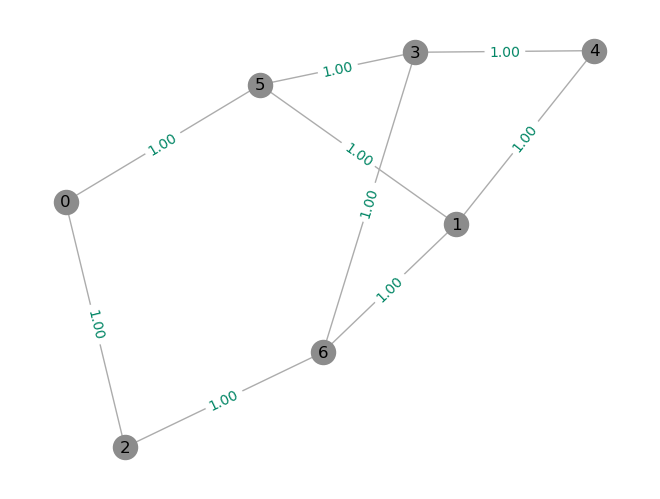

In [4]:
G = generate_graph(n, p)

edge_list = G.edges
nodes = list(G.nodes())
qubit_count = len(nodes)

qubit_source = list()
qubit_target = list()
n_edges = 0
for u, v in nx.edges(G):
    qubit_source.append(nodes.index(u))
    qubit_target.append(nodes.index(v))
    n_edges += 1

color_map = '#8c8c8c'
edge_color_map = '#acacac'
pos = nx.spring_layout(G, seed=seed)

edge_weights = nx.get_edge_attributes(G, 'weight')
nx.draw(
    G,
    with_labels=True,
    pos=pos,
    node_color=color_map,
    edge_color=edge_color_map,
)
nx.draw_networkx_edge_labels(
    G,
    pos,
    edge_labels={edge: f"{weight:.2f}" for edge, weight in edge_weights.items()},
    font_color=color_dict['G3'],
    font_size=10
)
plt.show()

In [5]:
nodes = list(G.nodes())
n_qubits = len(nodes)

optimal_parameters, node_map = optimize_qaoa(G, layer_count, seed)

qubit_source = list()
qubit_target = list()
edge_weights = list()
for u, v, data in G.edges(data=True):
    qubit_source.append(node_map[u])
    qubit_target.append(node_map[v])
    edge_weights.append(data.get('weight', 1.0))

counts = cudaq.sample(
    qaoa_kernel,
    n_qubits,
    layer_count,
    qubit_source,
    qubit_target,
    edge_weights,
    optimal_parameters,
    shots_count=1000
)

In [15]:
best_bitstring = counts.most_probable()

assignment = {}
for node in nodes:
    idx = node_map[node]
    bit_val = best_bitstring[len(best_bitstring) - 1 - idx]
    assignment[node] = -1 if bit_val == '1' else 1

In [16]:
assignment

{0: -1, 1: -1, 2: -1, 3: 1, 4: 1, 5: 1, 6: 1}

In [5]:
optimal_parameters, node_map = optimize_qaoa(G, layer_count, seed)
correlations = compute_correlations(G, optimal_parameters, layer_count, node_map)

In [6]:
max_edge = max(correlations, key=lambda e: abs(correlations[e]))
max_corr = correlations[max_edge]

In [7]:
u, v = max_edge
correlation_sign = np.sign(max_corr)
elimination_history.append((u, v, correlation_sign))
G_reduced = contract_graph(G, u, v, correlation_sign)

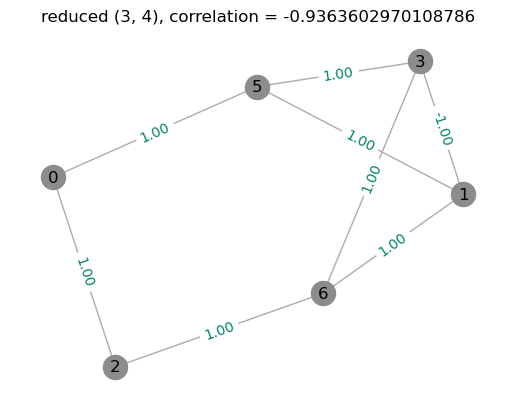

In [8]:
plt.title(f'reduced {u, v}, correlation = {max_corr}')
edge_weights = nx.get_edge_attributes(G_reduced, 'weight')
nx.draw(
    G_reduced,
    with_labels=True,
    pos=pos,
    node_color=color_map,
    edge_color=edge_color_map,
)
nx.draw_networkx_edge_labels(
    G_reduced,
    pos,
    edge_labels={edge: f"{weight:.2f}" for edge, weight in edge_weights.items()},
    font_color=color_dict['G3'],
    font_size=10
)
plt.show()